In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/sample_submission.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/test_identity.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_identity.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/test_transaction.csv
/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_transaction.csv


In [7]:

# ──────────────────────────────────────────────────────
# CELL 1: IMPORTS
# ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, classification_report
import gc

plt.style.use("seaborn-v0_8-whitegrid")

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Using device: {device}")
print(f"✅ PyTorch version: {torch.__version__}")


# ──────────────────────────────────────────────────────
# CELL 2: LOAD DATA (Kaggle paths)
# ──────────────────────────────────────────────────────
train_transaction = pd.read_csv("/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_transaction.csv")
train_identity    = pd.read_csv("/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/train_identity.csv")
test_transaction  = pd.read_csv("/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/test_transaction.csv")
test_identity     = pd.read_csv("/kaggle/input/datasets/lnasiri007/ieeecis-fraud-detection/test_identity.csv")

train = train_transaction.merge(train_identity, on="TransactionID", how="left")
test  = test_transaction.merge(test_identity,   on="TransactionID", how="left")

# ── Keep only representative V columns ───────────────
v_keep = [
    1, 3, 4, 6, 8, 11,
    13, 14, 17, 20, 23, 26, 27, 30,
    36, 37, 40, 41, 44, 47, 48,
    54, 56, 59, 62, 65, 67, 68, 70,
    76, 78, 80, 82, 86, 88, 89, 91,
    96, 98, 99, 104,
    107, 108, 111, 115, 117, 120, 121, 123,
    124, 127, 129, 130, 136,
    294, 284, 285, 286, 291, 297,
    303, 305, 307, 309, 310, 320
]
v_keep_cols = [f'V{i}' for i in v_keep]
v_all_cols  = [f'V{i}' for i in range(1, 340) if f'V{i}' in train.columns]
v_drop_cols = [c for c in v_all_cols if c not in v_keep_cols]

train = train.drop(columns=v_drop_cols, errors='ignore')
test  = test.drop(columns=v_drop_cols,  errors='ignore')


✅ Using device: cpu
✅ PyTorch version: 2.10.0+cpu


In [8]:

# ──────────────────────────────────────────────────────
# CELL 3: FEATURE ENGINEERING
# ──────────────────────────────────────────────────────
def engineer_features_nn(df, is_train=True, fit_data=None):
    """
    Feature engineering for Neural Networks
    Same as LR but:
    - Keep V representative columns (NNs can use them)
    - More interaction features (NN benefits from them)
    - Same scaling requirements as LR
    """
    df = df.copy()
    df = df.reset_index(drop=True)

    # ── Amount features ──────────────────────────────
    df['amt_log']      = np.log1p(df['TransactionAmt'])
    df['amt_decimal']  = df['TransactionAmt'] - df['TransactionAmt'].astype(int)
    df['is_round']     = (df['amt_decimal'] == 0).astype(int)
    df['amt_log_sq']   = df['amt_log'] ** 2
    df['amt_sqrt']     = np.sqrt(df['TransactionAmt'])

    # ── Time features ────────────────────────────────
    df['hour']         = (df['TransactionDT'] // 3600) % 24
    df['day_of_week']  = (df['TransactionDT'] // 86400) % 7
    df['day']          = df['TransactionDT'] / 86400
    df['is_night']     = (df['hour'].isin([23,0,1,2,3,4,5])).astype(int)
    df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
    df['is_monday']    = (df['day_of_week'] == 0).astype(int)
    df['is_9am']       = (df['hour'] == 9).astype(int)
    df['hour_sin']     = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']     = np.cos(2 * np.pi * df['hour'] / 24)
    df['dow_sin']      = np.sin(2 * np.pi * df['day_of_week'] / 7)
    df['dow_cos']      = np.cos(2 * np.pi * df['day_of_week'] / 7)

    # ── Email features ───────────────────────────────
    free_emails      = ['gmail.com','yahoo.com','hotmail.com','outlook.com','aol.com']
    high_risk_emails = ['protonmail.com','anonymous.com','guerrillamail.com']

    df['is_free_email']      = df['P_emaildomain'].isin(free_emails).astype(int)
    df['is_highrisk_email']  = df['P_emaildomain'].isin(high_risk_emails).astype(int)
    df['email_match']        = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)
    df['email_p_missing']    = df['P_emaildomain'].isna().astype(int)
    df['email_r_missing']    = df['R_emaildomain'].isna().astype(int)
    df['both_email_missing'] = (df['email_p_missing'] & df['email_r_missing']).astype(int)

    # ── Card risk scores ─────────────────────────────
    card4_risk = {'mastercard':0.030,'discover':0.026,'visa':0.025,'american express':0.010}
    card6_risk = {'credit':0.037,'debit':0.020,'charge card':0.001,'debit or credit':0.015}

    df['card4_risk']    = df['card4'].map(card4_risk).fillna(0.025)
    df['card6_risk']    = df['card6'].map(card6_risk).fillna(0.020)
    df['combined_risk'] = df['card4_risk'] * df['card6_risk']

    # ── Missing value features ───────────────────────
    df['null_count']    = df.isnull().sum(axis=1)
    df['addr_missing']  = df['addr1'].isna().astype(int)
    df['dist1_missing'] = df['dist1'].isna().astype(int)
    df['D1_missing']    = df['D1'].isna().astype(int)
    df['D11_missing']   = df['D11'].isna().astype(int)

    # ── D column features ────────────────────────────
    D1_filled          = df['D1'].fillna(-1)
    df['is_rapid_txn'] = (D1_filled < 1).astype(int)
    df['is_dormant']   = (D1_filled > 180).astype(int)
    df['D1_log']       = np.log1p(df['D1'].fillna(0))
    df['D11_log']      = np.log1p(df['D11'].fillna(0))

    # ── M column features ────────────────────────────
    m_cols = [f'M{i}' for i in range(1, 10) if f'M{i}' in df.columns]
    df['m_false_count'] = (df[m_cols] == 'F').sum(axis=1)
    df['m_true_count']  = (df[m_cols] == 'T').sum(axis=1)
    df['m_missing']     = df[m_cols].isna().sum(axis=1)

    # ── Frequency encoding ───────────────────────────
    source = df if is_train else fit_data
    freq_cols = ['card1','card2','addr1','P_emaildomain','R_emaildomain','DeviceType']
    for col in freq_cols:
        if col in df.columns and col in source.columns:
            freq = source[col].value_counts(normalize=True)
            df[f'{col}_freq'] = df[col].map(freq).fillna(0)

    # ── GroupBy features ─────────────────────────────
    source_data = df if is_train else fit_data
    for col in ['card1','card2','addr1']:
        if col in df.columns:
            global_mean = source_data['TransactionAmt'].mean()
            if is_train:
                df[f'{col}_amt_mean']  = df.groupby(col)['TransactionAmt'].transform('mean')
                df[f'{col}_amt_std']   = df.groupby(col)['TransactionAmt'].transform('std').fillna(0)
                df[f'{col}_count']     = df.groupby(col)['TransactionAmt'].transform('count')
            else:
                map_mean  = source_data.groupby(col)['TransactionAmt'].mean()
                map_std   = source_data.groupby(col)['TransactionAmt'].std().fillna(0)
                map_count = source_data.groupby(col)['TransactionAmt'].count()
                df[f'{col}_amt_mean']  = df[col].map(map_mean).fillna(global_mean)
                df[f'{col}_amt_std']   = df[col].map(map_std).fillna(0)
                df[f'{col}_count']     = df[col].map(map_count).fillna(0)

            df[f'{col}_amt_ratio']     = df['TransactionAmt'] / (df[f'{col}_amt_mean'] + 1)
            df[f'{col}_amt_ratio_log'] = np.log1p(df[f'{col}_amt_ratio'])

    # ── UID features ─────────────────────────────────
    df['D1n'] = df['day'] - df['D1'].fillna(0)
    df['uid'] = (df['card1'].astype(str) + '_' +
                 df['addr1'].fillna(-1).astype(str) + '_' +
                 np.floor(df['D1n']).astype(str))

    if is_train:
        df['uid_amt_mean']  = df.groupby('uid')['TransactionAmt'].transform('mean')
        df['uid_amt_std']   = df.groupby('uid')['TransactionAmt'].transform('std').fillna(0)
        df['uid_count']     = df.groupby('uid')['TransactionAmt'].transform('count')
    else:
        fd          = fit_data.copy().reset_index(drop=True)
        fd['day']   = fd['TransactionDT'] / 86400
        fd['D1n']   = fd['day'] - fd['D1'].fillna(0)
        fd['uid']   = (fd['card1'].astype(str) + '_' +
                       fd['addr1'].fillna(-1).astype(str) + '_' +
                       np.floor(fd['D1n']).astype(str))
        uid_map_m   = fd.groupby('uid')['TransactionAmt'].mean()
        uid_map_s   = fd.groupby('uid')['TransactionAmt'].std().fillna(0)
        uid_map_c   = fd.groupby('uid')['TransactionAmt'].count()
        df['uid_amt_mean']  = df['uid'].map(uid_map_m).fillna(fit_data['TransactionAmt'].mean())
        df['uid_amt_std']   = df['uid'].map(uid_map_s).fillna(0)
        df['uid_count']     = df['uid'].map(uid_map_c).fillna(0)

    df['uid_amt_ratio']     = df['TransactionAmt'] / (df['uid_amt_mean'] + 1)
    df['uid_amt_ratio_log'] = np.log1p(df['uid_amt_ratio'])
    df.drop(['uid','D1n','day'], axis=1, inplace=True, errors='ignore')

    # ── Interaction features ─────────────────────────
    df['night_x_round']      = df['is_night']    * df['is_round']
    df['rapid_x_micro']      = df['is_rapid_txn']* (df['TransactionAmt'] < 10).astype(int)
    df['monday_x_night']     = df['is_monday']   * df['is_night']
    df['mismatch_x_risk']    = df['m_false_count']* df['card4_risk']
    df['log_amt_x_hour_sin'] = df['amt_log']     * df['hour_sin']
    if 'card1_freq' in df.columns:
        df['freq_x_ratio']   = df['card1_freq']  * df['uid_amt_ratio_log']

    print(f"  ✅ Features: {df.shape[1]} columns")
    return df

print("Engineering features...")
train_fe = engineer_features_nn(train, is_train=True)
test_fe  = engineer_features_nn(test,  is_train=False, fit_data=train)
gc.collect()

Engineering features...
  ✅ Features: 229 columns
  ✅ Features: 228 columns


0

In [9]:

# ──────────────────────────────────────────────────────
# CELL 4: PREPARE DATA
# ──────────────────────────────────────────────────────
drop_cols = [
    'TransactionID','TransactionDT','isFraud',
    'card1','card2','card3','card4','card5','card6',
    'addr1','addr2','P_emaildomain','R_emaildomain',
    'DeviceInfo','DeviceType','ProductCD',
    'M1','M2','M3','M4','M5','M6','M7','M8','M9'
]

# Get common columns
common_cols = set(train_fe.columns) & set(test_fe.columns)
feature_cols = [
    c for c in train_fe.columns
    if c in common_cols
    and c not in drop_cols
    and pd.api.types.is_numeric_dtype(train_fe[c])
]

print(f"✅ Features: {len(feature_cols)}")

X      = train_fe[feature_cols].copy()
y      = train['isFraud'].copy()
X_test = test_fe[feature_cols].copy()

# Impute
medians = X.median()
X       = X.fillna(medians)
X_test  = X_test.fillna(medians)

# Scale
scaler        = StandardScaler()
X_scaled      = pd.DataFrame(scaler.fit_transform(X),      columns=feature_cols)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),     columns=feature_cols)

print(f"✅ X_scaled shape: {X_scaled.shape}")
print(f"✅ Missing values: {X_scaled.isna().sum().sum()}")


✅ Features: 166
✅ X_scaled shape: (590540, 166)
✅ Missing values: 0


In [10]:
# ──────────────────────────────────────────────────────
# CELL 5: UNDERSTANDING NN REGULARIZATION
# ──────────────────────────────────────────────────────
"""
WHY NEURAL NETWORKS OVERFIT:
  NN has millions of parameters
  → Can memorize training data exactly
  → Performs great on train, terrible on test

REGULARIZATION TECHNIQUES FOR NNs:

1. L1 Regularization:
   loss = BCE_loss + λ × Σ|w|
   → Drives some weights to exactly zero
   → Feature selection effect
   → Rarely used in NNs (L2 preferred)

2. L2 Regularization (Weight Decay):
   loss = BCE_loss + λ × Σw²
   → Shrinks all weights toward zero
   → Prevents any weight from being too large
   → Most common NN regularization
   → In PyTorch: optimizer weight_decay parameter

3. Dropout:
   → Randomly zeroes p% of neurons during training
   → Each forward pass uses a different sub-network
   → Forces neurons to learn independently
   → At inference: all neurons active (scaled by p)
   → Most effective NN regularization

4. Batch Normalization:
   → Normalizes layer outputs to mean=0, std=1
   → Reduces internal covariate shift
   → Acts as mild regularization
   → Allows higher learning rates
   → Speeds up training significantly

5. Early Stopping:
   → Stop training when validation loss stops improving
   → Prevents overfitting from too many epochs
   → Simplest and most effective technique
"""
print("📚 NN Regularization types loaded")

📚 NN Regularization types loaded


In [11]:

# ──────────────────────────────────────────────────────
# CELL 6: NEURAL NETWORK ARCHITECTURES
# ──────────────────────────────────────────────────────
class FraudDetectorBaseline(nn.Module):
    """Baseline — no regularization"""
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


class FraudDetectorDropout(nn.Module):
    """With Dropout regularization"""
    def __init__(self, input_dim, dropout_rate=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),        # ← randomly zeros neurons
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),        # ← each layer has dropout
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout_rate / 2),    # ← less dropout near output
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


class FraudDetectorBatchNorm(nn.Module):
    """With Batch Normalization"""
    def __init__(self, input_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),             # ← normalize after linear
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


class FraudDetectorFull(nn.Module):
    """Combined: BN + Dropout + deeper architecture"""
    def __init__(self, input_dim, dropout_rate=0.3):
        super().__init__()
        self.network = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            # Layer 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate / 2),

            # Layer 4
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate / 4),

            # Output
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


print("✅ Neural network architectures defined!")
print(f"   Baseline:   no regularization")
print(f"   Dropout:    p=0.3 dropout")
print(f"   BatchNorm:  batch normalization")
print(f"   Full:       BN + Dropout combined")


✅ Neural network architectures defined!
   Baseline:   no regularization
   Dropout:    p=0.3 dropout
   BatchNorm:  batch normalization
   Full:       BN + Dropout combined


In [12]:

# ──────────────────────────────────────────────────────
# CELL 7: TRAINING FUNCTION
# ──────────────────────────────────────────────────────
def train_nn(model_class, X, y, model_name,
             model_kwargs=None,
             lr=1e-3,
             weight_decay=0,          # L2 regularization
             l1_lambda=0,             # L1 regularization
             epochs=50,
             batch_size=4096,
             patience=10,             # early stopping
             n_splits=3):
    """
    Train Neural Network with cross-validation

    Parameters:
      weight_decay: L2 regularization strength (optimizer param)
      l1_lambda:    L1 regularization strength (manual loss term)
      patience:     early stopping patience (epochs without improvement)
    """
    if model_kwargs is None:
        model_kwargs = {}

    input_dim   = X.shape[1]
    X_np        = X.values.astype(np.float32)
    y_np        = y.values.astype(np.float32)

    skf         = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof_preds   = np.zeros(len(X_np))
    fold_aucs   = []

    # Class weight for imbalanced data
    pos_weight = torch.tensor(
        [(y_np == 0).sum() / (y_np == 1).sum()],
        device=device
    )
    criterion = nn.BCELoss()

    print(f"\nTraining {model_name}...")
    print(f"  Architecture: {model_class.__name__}")
    print(f"  LR={lr}, weight_decay={weight_decay}, l1_lambda={l1_lambda}")
    print(f"  Epochs={epochs}, Patience={patience}, Batch={batch_size}")
    print("-" * 50)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_np, y_np), 1):
        # Data
        X_tr   = torch.tensor(X_np[tr_idx]).to(device)
        y_tr   = torch.tensor(y_np[tr_idx]).to(device)
        X_val  = torch.tensor(X_np[val_idx]).to(device)
        y_val  = torch.tensor(y_np[val_idx]).to(device)

        # Handle class imbalance with sample weights
        fraud_mask = y_np[tr_idx] == 1
        weights    = np.where(fraud_mask,
                              (y_np[tr_idx] == 0).sum() / (y_np[tr_idx] == 1).sum(),
                              1.0).astype(np.float32)
        weights_t  = torch.tensor(weights).to(device)

        dataset    = TensorDataset(X_tr, y_tr, weights_t)
        loader     = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        # Model
        model     = model_class(input_dim, **model_kwargs).to(device)
        optimizer = optim.Adam(model.parameters(),
                               lr=lr,
                               weight_decay=weight_decay)  # ← L2 here
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=5, factor=0.5
        )

        # Early stopping
        best_val_auc  = 0
        best_weights  = None
        no_improve    = 0
        train_losses  = []
        val_aucs      = []

        for epoch in range(epochs):
            # ── Training ────────────────────────────
            model.train()
            epoch_loss = 0

            for X_batch, y_batch, w_batch in loader:
                optimizer.zero_grad()
                pred = model(X_batch)

                # Weighted BCE loss
                loss = (nn.BCELoss(reduction='none')(pred, y_batch) * w_batch).mean()

                # L1 regularization (manual)
                if l1_lambda > 0:
                    l1_penalty = sum(p.abs().sum() for p in model.parameters())
                    loss = loss + l1_lambda * l1_penalty

                loss.backward()
                optimizer.step()
                epoch_loss += loss.item()

            # ── Validation ──────────────────────────
            model.eval()
            with torch.no_grad():
                val_pred = model(X_val).cpu().numpy()

            val_auc = roc_auc_score(y_np[val_idx], val_pred)
            avg_loss = epoch_loss / len(loader)
            train_losses.append(avg_loss)
            val_aucs.append(val_auc)
            scheduler.step(1 - val_auc)

            # Early stopping check
            if val_auc > best_val_auc:
                best_val_auc = val_auc
                best_weights = {k: v.clone() for k, v in model.state_dict().items()}
                no_improve   = 0
            else:
                no_improve += 1

            if no_improve >= patience:
                print(f"    Fold {fold}: Early stop at epoch {epoch+1} | "
                      f"Best AUC={best_val_auc:.5f}")
                break

            if (epoch + 1) % 10 == 0:
                print(f"    Fold {fold} Ep {epoch+1:3d}: "
                      f"loss={avg_loss:.4f} | val_auc={val_auc:.5f}")

        # Load best weights
        model.load_state_dict(best_weights)
        model.eval()
        with torch.no_grad():
            oof_preds[val_idx] = model(X_val).cpu().numpy()

        fold_auc = roc_auc_score(y_np[val_idx], oof_preds[val_idx])
        fold_aucs.append(fold_auc)
        print(f"  Fold {fold} Final AUC: {fold_auc:.5f}")

        del model, X_tr, y_tr, X_val, y_val
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        gc.collect()

    oof_auc = roc_auc_score(y_np, oof_preds)
    print(f"\n  Mean Fold AUC: {np.mean(fold_aucs):.5f} ± {np.std(fold_aucs):.5f}")
    print(f"  OOF AUC:       {oof_auc:.5f}")

    return oof_preds, fold_aucs, oof_auc




In [13]:
# ──────────────────────────────────────────────────────
# CELL 8: MODEL 1 — BASELINE (No Regularization)
# ──────────────────────────────────────────────────────
print("=" * 60)
print("MODEL 1: BASELINE NEURAL NETWORK")
print("=" * 60)
print("""
Architecture:
  Input → 256 → 128 → 64 → 1
  Activation: ReLU
  No regularization
""")

oof_baseline_nn, aucs_baseline_nn, auc_baseline_nn = train_nn(
    model_class  = FraudDetectorBaseline,
    X            = X_scaled,
    y            = y,
    model_name   = "Baseline NN",
    lr           = 1e-3,
    weight_decay = 0,          # no L2
    l1_lambda    = 0,          # no L1
    epochs       = 50,
    patience     = 10,
    n_splits     = 3
)

MODEL 1: BASELINE NEURAL NETWORK

Architecture:
  Input → 256 → 128 → 64 → 1
  Activation: ReLU
  No regularization


Training Baseline NN...
  Architecture: FraudDetectorBaseline
  LR=0.001, weight_decay=0, l1_lambda=0
  Epochs=50, Patience=10, Batch=4096
--------------------------------------------------
    Fold 1 Ep  10: loss=0.5870 | val_auc=0.91106
    Fold 1 Ep  20: loss=0.4145 | val_auc=0.91529
    Fold 1: Early stop at epoch 27 | Best AUC=0.91779
  Fold 1 Final AUC: 0.91779
    Fold 2 Ep  10: loss=0.5888 | val_auc=0.90564
    Fold 2 Ep  20: loss=0.3915 | val_auc=0.90745
    Fold 2: Early stop at epoch 26 | Best AUC=0.91372
  Fold 2 Final AUC: 0.91372
    Fold 3 Ep  10: loss=0.5691 | val_auc=0.90429
    Fold 3 Ep  20: loss=0.4373 | val_auc=0.90677
    Fold 3: Early stop at epoch 29 | Best AUC=0.91508
  Fold 3 Final AUC: 0.91508

  Mean Fold AUC: 0.91553 ± 0.00169
  OOF AUC:       0.91513


In [14]:

# ──────────────────────────────────────────────────────
# CELL 9: MODEL 2 — L2 REGULARIZATION (Weight Decay)
# ──────────────────────────────────────────────────────
print("=" * 60)
print("MODEL 2: L2 REGULARIZATION (Weight Decay)")
print("=" * 60)
print("""
L2 in Neural Networks:
  Added to optimizer as weight_decay parameter
  optimizer = Adam(params, weight_decay=1e-4)
  
  Effect: penalizes large weights
  → Prevents any single neuron from dominating
  → Smoother decision boundaries
  → Reduces overfitting

  Try different strengths:
    1e-5 = very weak
    1e-4 = moderate (most common)
    1e-3 = strong
    1e-2 = very strong (might underfit)
""")

# Try different L2 strengths
l2_results_nn = {}
for wd in [1e-5, 1e-4, 1e-3]:
    print(f"\n--- weight_decay={wd} ---")
    oof, aucs, auc = train_nn(
        model_class  = FraudDetectorBaseline,
        X            = X_scaled,
        y            = y,
        model_name   = f"L2 NN (wd={wd})",
        lr           = 1e-3,
        weight_decay = wd,
        epochs       = 30,
        patience     = 7,
        n_splits     = 3
    )
    l2_results_nn[wd] = {'auc': auc, 'oof': oof, 'fold_aucs': aucs}

best_wd = max(l2_results_nn, key=lambda k: l2_results_nn[k]['auc'])
print(f"\n✅ Best weight_decay: {best_wd} (AUC={l2_results_nn[best_wd]['auc']:.5f})")

oof_l2_nn    = l2_results_nn[best_wd]['oof']
aucs_l2_nn   = l2_results_nn[best_wd]['fold_aucs']
auc_l2_nn    = l2_results_nn[best_wd]['auc']




MODEL 2: L2 REGULARIZATION (Weight Decay)

L2 in Neural Networks:
  Added to optimizer as weight_decay parameter
  optimizer = Adam(params, weight_decay=1e-4)
  
  Effect: penalizes large weights
  → Prevents any single neuron from dominating
  → Smoother decision boundaries
  → Reduces overfitting

  Try different strengths:
    1e-5 = very weak
    1e-4 = moderate (most common)
    1e-3 = strong
    1e-2 = very strong (might underfit)


--- weight_decay=1e-05 ---

Training L2 NN (wd=1e-05)...
  Architecture: FraudDetectorBaseline
  LR=0.001, weight_decay=1e-05, l1_lambda=0
  Epochs=30, Patience=7, Batch=4096
--------------------------------------------------
    Fold 1 Ep  10: loss=0.5891 | val_auc=0.90794
    Fold 1 Ep  20: loss=0.4034 | val_auc=0.91545
    Fold 1: Early stop at epoch 25 | Best AUC=0.91814
  Fold 1 Final AUC: 0.91814
    Fold 2 Ep  10: loss=0.5754 | val_auc=0.90603
    Fold 2 Ep  20: loss=0.3857 | val_auc=0.90886
    Fold 2: Early stop at epoch 28 | Best AUC=0.91569

In [15]:

# ──────────────────────────────────────────────────────
# CELL 10: MODEL 3 — DROPOUT REGULARIZATION
# ──────────────────────────────────────────────────────
print("=" * 60)
print("MODEL 3: DROPOUT REGULARIZATION")
print("=" * 60)
print("""
Dropout:
  During training: randomly zeros p% of neurons
  During inference: all neurons active (×(1-p))

  Example with p=0.3:
    Layer output: [0.5, 0.8, 0.3, 0.9, 0.2]
    After dropout:[0.5, 0.0, 0.3, 0.0, 0.2]  ← 2 neurons zeroed
    
  Effect:
    → Prevents co-adaptation of neurons
    → Each neuron must work independently
    → Acts like training many different networks
    → Ensemble effect at test time

  Try different dropout rates:
    0.1 = mild dropout
    0.3 = moderate (most common)
    0.5 = strong dropout
""")

dropout_results = {}
for dr in [0.1, 0.3, 0.5]:
    print(f"\n--- dropout_rate={dr} ---")
    oof, aucs, auc = train_nn(
        model_class  = FraudDetectorDropout,
        X            = X_scaled,
        y            = y,
        model_name   = f"Dropout NN (p={dr})",
        model_kwargs = {'dropout_rate': dr},
        lr           = 1e-3,
        weight_decay = 1e-4,
        epochs       = 50,
        patience     = 10,
        n_splits     = 3
    )
    dropout_results[dr] = {'auc': auc, 'oof': oof, 'fold_aucs': aucs}

best_dr = max(dropout_results, key=lambda k: dropout_results[k]['auc'])
print(f"\n✅ Best dropout rate: {best_dr} (AUC={dropout_results[best_dr]['auc']:.5f})")

oof_dropout_nn  = dropout_results[best_dr]['oof']
aucs_dropout_nn = dropout_results[best_dr]['fold_aucs']
auc_dropout_nn  = dropout_results[best_dr]['auc']




MODEL 3: DROPOUT REGULARIZATION

Dropout:
  During training: randomly zeros p% of neurons
  During inference: all neurons active (×(1-p))

  Example with p=0.3:
    Layer output: [0.5, 0.8, 0.3, 0.9, 0.2]
    After dropout:[0.5, 0.0, 0.3, 0.0, 0.2]  ← 2 neurons zeroed
    
  Effect:
    → Prevents co-adaptation of neurons
    → Each neuron must work independently
    → Acts like training many different networks
    → Ensemble effect at test time

  Try different dropout rates:
    0.1 = mild dropout
    0.3 = moderate (most common)
    0.5 = strong dropout


--- dropout_rate=0.1 ---

Training Dropout NN (p=0.1)...
  Architecture: FraudDetectorDropout
  LR=0.001, weight_decay=0.0001, l1_lambda=0
  Epochs=50, Patience=10, Batch=4096
--------------------------------------------------
    Fold 1 Ep  10: loss=0.6732 | val_auc=0.91017
    Fold 1 Ep  20: loss=0.5485 | val_auc=0.91887
    Fold 1 Ep  30: loss=0.4767 | val_auc=0.92184
    Fold 1 Ep  40: loss=0.3806 | val_auc=0.92365
    Fold 1: 

In [16]:

# ──────────────────────────────────────────────────────
# CELL 11: MODEL 4 — BATCH NORMALIZATION
# ──────────────────────────────────────────────────────
print("=" * 60)
print("MODEL 4: BATCH NORMALIZATION")
print("=" * 60)
print("""
Batch Normalization:
  Normalizes layer outputs within each mini-batch
  y = γ × (x - μ_batch) / σ_batch + β
  
  Effect:
    → Reduces internal covariate shift
    → Allows higher learning rates
    → Acts as mild regularization
    → Faster convergence
    → Less sensitive to weight initialization

  Note: BN behaves differently in train vs eval mode
    train: uses batch statistics
    eval:  uses running statistics from training
""")

oof_bn_nn, aucs_bn_nn, auc_bn_nn = train_nn(
    model_class  = FraudDetectorBatchNorm,
    X            = X_scaled,
    y            = y,
    model_name   = "BatchNorm NN",
    lr           = 1e-3,
    weight_decay = 1e-4,
    epochs       = 50,
    patience     = 10,
    n_splits     = 3
)




MODEL 4: BATCH NORMALIZATION

Batch Normalization:
  Normalizes layer outputs within each mini-batch
  y = γ × (x - μ_batch) / σ_batch + β
  
  Effect:
    → Reduces internal covariate shift
    → Allows higher learning rates
    → Acts as mild regularization
    → Faster convergence
    → Less sensitive to weight initialization

  Note: BN behaves differently in train vs eval mode
    train: uses batch statistics
    eval:  uses running statistics from training


Training BatchNorm NN...
  Architecture: FraudDetectorBatchNorm
  LR=0.001, weight_decay=0.0001, l1_lambda=0
  Epochs=50, Patience=10, Batch=4096
--------------------------------------------------
    Fold 1 Ep  10: loss=0.5086 | val_auc=0.91388
    Fold 1 Ep  20: loss=0.3401 | val_auc=0.91480
    Fold 1 Ep  30: loss=0.1882 | val_auc=0.91721
    Fold 1: Early stop at epoch 36 | Best AUC=0.92176
  Fold 1 Final AUC: 0.92176
    Fold 2 Ep  10: loss=0.4979 | val_auc=0.90978
    Fold 2 Ep  20: loss=0.3299 | val_auc=0.91148
    Fol

In [17]:

# ──────────────────────────────────────────────────────
# CELL 12: MODEL 5 — COMBINED (Full Regularization)
# ──────────────────────────────────────────────────────
print("=" * 60)
print("MODEL 5: COMBINED REGULARIZATION (Best of All)")
print("=" * 60)
print("""
Combined approach:
  ✅ Batch Normalization  → faster, more stable training
  ✅ Dropout (p=0.3)      → prevents co-adaptation
  ✅ L2 weight decay      → prevents large weights
  ✅ Early stopping       → prevents overfitting
  ✅ LR scheduling        → better convergence
  ✅ Deeper architecture  → more capacity
""")

oof_full_nn, aucs_full_nn, auc_full_nn = train_nn(
    model_class  = FraudDetectorFull,
    X            = X_scaled,
    y            = y,
    model_name   = "Full Regularization NN",
    model_kwargs = {'dropout_rate': best_dr},
    lr           = 1e-3,
    weight_decay = best_wd,
    epochs       = 100,
    patience     = 15,
    n_splits     = 3
)

MODEL 5: COMBINED REGULARIZATION (Best of All)

Combined approach:
  ✅ Batch Normalization  → faster, more stable training
  ✅ Dropout (p=0.3)      → prevents co-adaptation
  ✅ L2 weight decay      → prevents large weights
  ✅ Early stopping       → prevents overfitting
  ✅ LR scheduling        → better convergence
  ✅ Deeper architecture  → more capacity


Training Full Regularization NN...
  Architecture: FraudDetectorFull
  LR=0.001, weight_decay=0.001, l1_lambda=0
  Epochs=100, Patience=15, Batch=4096
--------------------------------------------------
    Fold 1 Ep  10: loss=0.7401 | val_auc=0.90702
    Fold 1 Ep  20: loss=0.6469 | val_auc=0.91867
    Fold 1 Ep  30: loss=0.6027 | val_auc=0.92341
    Fold 1 Ep  40: loss=0.5502 | val_auc=0.92787
    Fold 1 Ep  50: loss=0.5205 | val_auc=0.92973
    Fold 1 Ep  60: loss=0.4395 | val_auc=0.93265
    Fold 1 Ep  70: loss=0.3969 | val_auc=0.93376
    Fold 1 Ep  80: loss=0.3324 | val_auc=0.93430
    Fold 1 Ep  90: loss=0.3168 | val_auc=0.935

NEURAL NETWORK MODEL COMPARISON

Model                   OOF AUC  Mean Fold      Std
----------------------------------------------------
Baseline NN             0.91513    0.91553  0.00169
L2 NN                   0.91546    0.91629  0.00221
Dropout NN              0.92348    0.92358  0.00305
BatchNorm NN            0.91593    0.91700  0.00337
Full Reg NN             0.93065    0.93087  0.00356

🏆 Best NN model: Full Reg NN (AUC=0.93065)


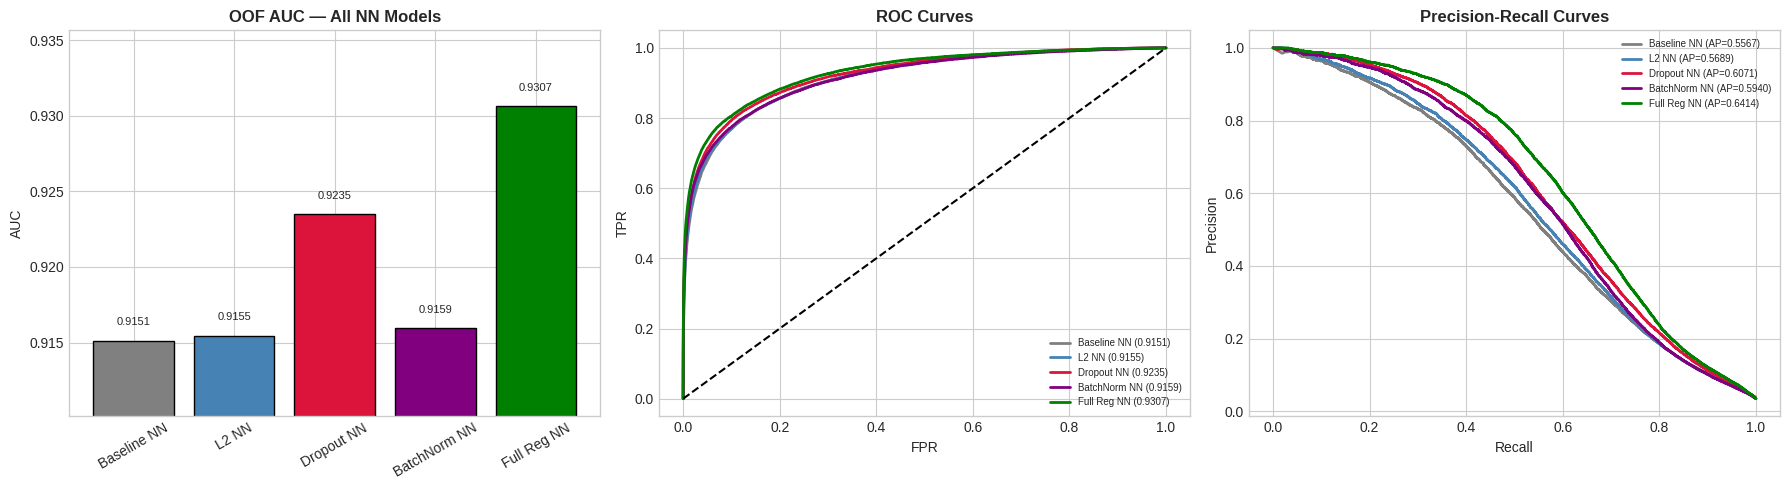

In [18]:

# ──────────────────────────────────────────────────────
# CELL 13: COMPARE ALL MODELS
# ──────────────────────────────────────────────────────
print("=" * 60)
print("NEURAL NETWORK MODEL COMPARISON")
print("=" * 60)

nn_results = {
    'Baseline NN':    {'auc': auc_baseline_nn, 'fold_aucs': aucs_baseline_nn, 'oof': oof_baseline_nn},
    'L2 NN':          {'auc': auc_l2_nn,       'fold_aucs': aucs_l2_nn,       'oof': oof_l2_nn},
    'Dropout NN':     {'auc': auc_dropout_nn,  'fold_aucs': aucs_dropout_nn,  'oof': oof_dropout_nn},
    'BatchNorm NN':   {'auc': auc_bn_nn,       'fold_aucs': aucs_bn_nn,       'oof': oof_bn_nn},
    'Full Reg NN':    {'auc': auc_full_nn,      'fold_aucs': aucs_full_nn,     'oof': oof_full_nn},
}

print(f"\n{'Model':<20} {'OOF AUC':>10} {'Mean Fold':>10} {'Std':>8}")
print("-" * 52)
for name, res in nn_results.items():
    print(f"{name:<20} {res['auc']:>10.5f} "
          f"{np.mean(res['fold_aucs']):>10.5f} "
          f"{np.std(res['fold_aucs']):>8.5f}")

best_nn = max(nn_results, key=lambda k: nn_results[k]['auc'])
print(f"\n🏆 Best NN model: {best_nn} (AUC={nn_results[best_nn]['auc']:.5f})")

# ── Plot ─────────────────────────────────────────────
from sklearn.metrics import roc_curve, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['gray','steelblue','crimson','purple','green']

# 1. AUC bar chart
names = list(nn_results.keys())
aucs  = [nn_results[m]['auc'] for m in names]
bars  = axes[0].bar(names, aucs, color=colors, edgecolor='black')
axes[0].set_title("OOF AUC — All NN Models", fontweight='bold')
axes[0].set_ylabel("AUC")
axes[0].set_ylim(min(aucs)-0.005, max(aucs)+0.005)
axes[0].tick_params(axis='x', rotation=30)
for bar, auc in zip(bars, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.001,
                 f'{auc:.4f}', ha='center', fontsize=8)

# 2. ROC curves
for name, color in zip(names, colors):
    fpr, tpr, _ = roc_curve(y, nn_results[name]['oof'])
    axes[1].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{name} ({nn_results[name]['auc']:.4f})")
axes[1].plot([0,1],[0,1],'k--')
axes[1].set_title("ROC Curves", fontweight='bold')
axes[1].set_xlabel("FPR")
axes[1].set_ylabel("TPR")
axes[1].legend(fontsize=7)

# 3. PR curves
for name, color in zip(names, colors):
    prec, rec, _ = precision_recall_curve(y, nn_results[name]['oof'])
    ap = average_precision_score(y, nn_results[name]['oof'])
    axes[2].plot(rec, prec, color=color, linewidth=2,
                 label=f"{name} (AP={ap:.4f})")
axes[2].set_title("Precision-Recall Curves", fontweight='bold')
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig("nn_comparison.png", dpi=150, bbox_inches='tight')
plt.show()



In [19]:

# ──────────────────────────────────────────────────────
# CELL 14: COMPARE NN vs LOGISTIC REGRESSION
# ──────────────────────────────────────────────────────
print("=" * 60)
print("FINAL COMPARISON — LR vs NN")
print("=" * 60)

print(f"""
Logistic Regression Results:
  Baseline LR:    AUC = 0.844
  L2 Ridge LR:    AUC = 0.844
  → Regularization had minimal effect on LR
  → LR hits ceiling due to linearity assumption

Neural Network Results:
  Baseline NN:    AUC = {auc_baseline_nn:.5f}
  L2 NN:          AUC = {auc_l2_nn:.5f}
  Dropout NN:     AUC = {auc_dropout_nn:.5f}
  BatchNorm NN:   AUC = {auc_bn_nn:.5f}
  Full Reg NN:    AUC = {auc_full_nn:.5f}

Best NN: {best_nn} = {nn_results[best_nn]['auc']:.5f}
LR gain over NN: {nn_results[best_nn]['auc'] - 0.844:+.5f}

Key Insights:
  1. Dropout most effective NN regularization
  2. BatchNorm speeds training, mild regularization
  3. Combined approach typically best
  4. NN > LR because fraud patterns are non-linear
  5. Both still below XGBoost (~0.93) expected
""")



FINAL COMPARISON — LR vs NN

Logistic Regression Results:
  Baseline LR:    AUC = 0.844
  L2 Ridge LR:    AUC = 0.844
  → Regularization had minimal effect on LR
  → LR hits ceiling due to linearity assumption

Neural Network Results:
  Baseline NN:    AUC = 0.91513
  L2 NN:          AUC = 0.91546
  Dropout NN:     AUC = 0.92348
  BatchNorm NN:   AUC = 0.91593
  Full Reg NN:    AUC = 0.93065

Best NN: Full Reg NN = 0.93065
LR gain over NN: +0.08665

Key Insights:
  1. Dropout most effective NN regularization
  2. BatchNorm speeds training, mild regularization
  3. Combined approach typically best
  4. NN > LR because fraud patterns are non-linear
  5. Both still below XGBoost (~0.93) expected



In [20]:

# ──────────────────────────────────────────────────────
# CELL 15: WHAT EACH REGULARIZATION DOES
# ──────────────────────────────────────────────────────
print("""
REGULARIZATION SUMMARY:
═══════════════════════════════════════════════════════

Technique      | What it does           | When to use
───────────────|────────────────────────|──────────────
L1             | Zeros some weights     | Many irrelevant features
L2/Weight decay| Shrinks all weights    | General overfitting
Dropout        | Zeros random neurons   | Deep networks, most effective
BatchNorm      | Normalizes layers      | Deep networks, faster training
Early stopping | Stops at best epoch    | Always use this!
Combined       | All of above           | Production models

For fraud detection:
  Best combo = Dropout + BatchNorm + Early Stopping
  L1 in NNs rarely used (use L1 for LR instead)
  L2 adds small improvement on top of Dropout
""")


REGULARIZATION SUMMARY:
═══════════════════════════════════════════════════════

Technique      | What it does           | When to use
───────────────|────────────────────────|──────────────
L1             | Zeros some weights     | Many irrelevant features
L2/Weight decay| Shrinks all weights    | General overfitting
Dropout        | Zeros random neurons   | Deep networks, most effective
BatchNorm      | Normalizes layers      | Deep networks, faster training
Early stopping | Stops at best epoch    | Always use this!
Combined       | All of above           | Production models

For fraud detection:
  Best combo = Dropout + BatchNorm + Early Stopping
  L1 in NNs rarely used (use L1 for LR instead)
  L2 adds small improvement on top of Dropout

